#Data Loading

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [10]:
import pandas as pd
df = pd.read_csv("G:\Python Projects\olympic-dashboard\data\preprocessed_athlete_events.csv")
print(df.head())

                       Name Sex   Age  Height  Weight            Team  NOC  \
0                 A Dijiang   M  24.0   180.0    80.0           China  CHN   
1                  A Lamusi   M  23.0   170.0    60.0           China  CHN   
2       Gunnar Nielsen Aaby   M  24.0    -1.0    -1.0         Denmark  DEN   
3      Edgar Lindenau Aabye   M  34.0    -1.0    -1.0  Denmark/Sweden  DEN   
4  Christine Jacoba Aaftink   F  21.0   185.0    82.0     Netherlands  NED   

   Year  Season       City          Sport                             Event  \
0  1992  Summer  Barcelona     Basketball       Basketball Men's Basketball   
1  2012  Summer     London           Judo      Judo Men's Extra-Lightweight   
2  1920  Summer  Antwerpen       Football           Football Men's Football   
3  1900  Summer      Paris     Tug-Of-War       Tug-Of-War Men's Tug-Of-War   
4  1988  Winter    Calgary  Speed Skating  Speed Skating Women's 500 metres   

     Medal  
0  MISSING  
1  MISSING  
2  MISSING  
3   

#EDA

In [5]:
print(f"Shape of df is{df.shape}")
df.describe()

Shape of df is(25083, 13)


,Age,Height,Weight,Year
count,25082.000000,25082.000000,25082.000000,25082.000000
mean,24.522566,135.424368,54.006419,1978.846982
std,8.058629,74.569258,33.029783,29.356273
min,-1.000000,-1.000000,-1.000000,1896.000000
25%,21.000000,157.000000,46.000000,1960.000000
50%,24.000000,171.000000,65.000000,1988.000000
75%,28.000000,180.000000,75.000000,2002.000000
max,84.000000,221.000000,214.000000,2016.000000


In [9]:

eda_summary = {
    "Averages (Mean)": df.mean(numeric_only=True),
    "Unique Values": df.nunique()
}
eda_summary_df = pd.DataFrame(eda_summary)
print("Basic EDA Summaries:")
print(eda_summary_df)

Basic EDA Summaries:
        Averages (Mean)  Unique Values
Age           24.522566             61
City                NaN             42
Event               NaN            678
Height       135.424368             81
Medal               NaN              4
NOC                 NaN            218
Name                NaN          13094
Season              NaN              2
Sex                 NaN              2
Sport               NaN             62
Team                NaN            490
Weight        54.006419            138
Year        1978.846982             35


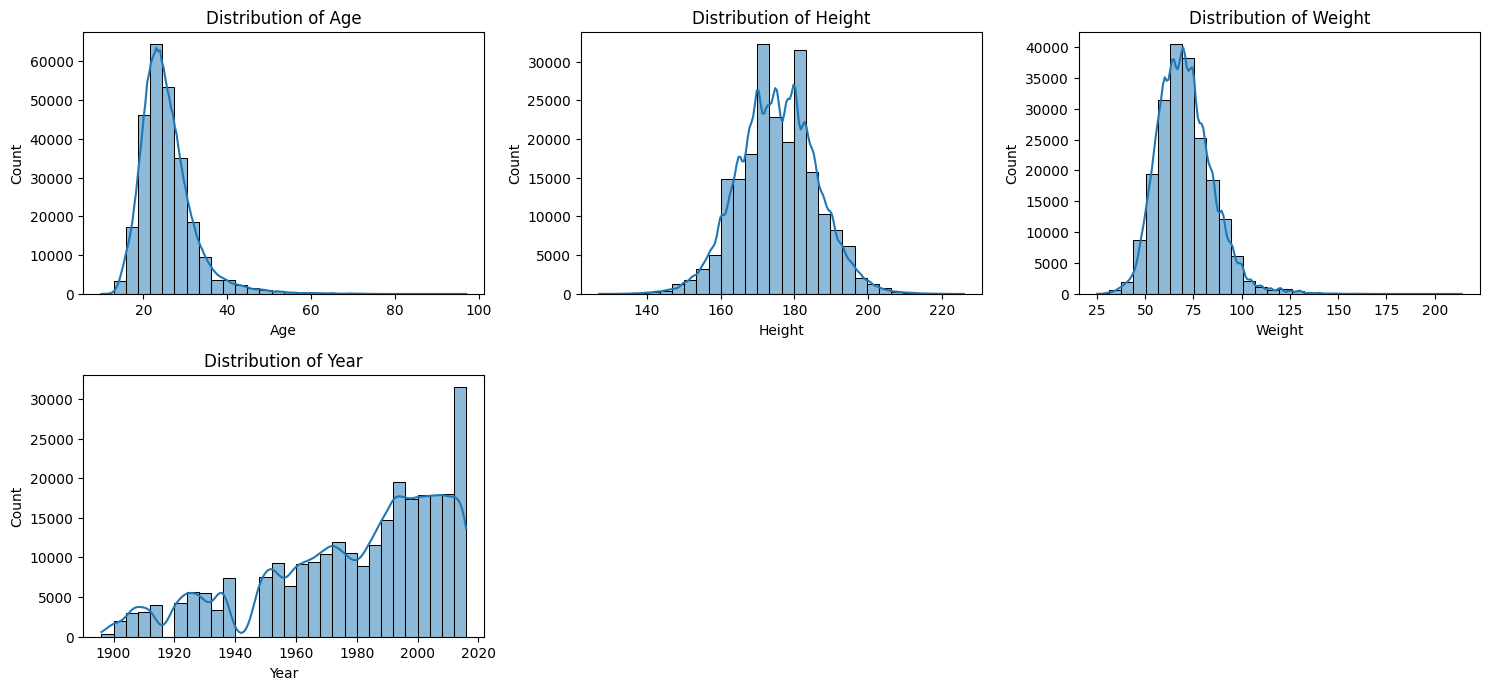

In [ ]:
# Select numeric features
numeric_features = df.select_dtypes(include=np.number)

# Create distribution plots
plt.figure(figsize=(15, 10))
for i, column in enumerate(numeric_features.columns, 1):
    plt.subplot(3, 3, i)
    sns.histplot(numeric_features[column].dropna(), kde=True, bins=30)
    plt.title(f"Distribution of {column}")
plt.tight_layout()
plt.show()

In [ ]:
# Mode values and unique counts for categorical columns
categorical_modes = df.select_dtypes(include="object").mode().iloc[0]
unique_values_per_cat = df.select_dtypes(include="object").nunique()

# Create a DataFrame for categorical modes and unique values
cat_modes_df = pd.DataFrame({
    "Mode": categorical_modes,
    "Unique Values": unique_values_per_cat
})
print("Categorical Modes and Unique Values:")
print(cat_modes_df)


Categorical Modes and Unique Values:
                           Mode  Unique Values
Name       Robert Tait McKenzie         134732
Sex                           M              2
Team              United States           1184
NOC                         USA            230
Season                   Summer              2
City                     London             42
Sport                 Athletics             66
Event   Football Men's Football            765
Medal                      Gold              3


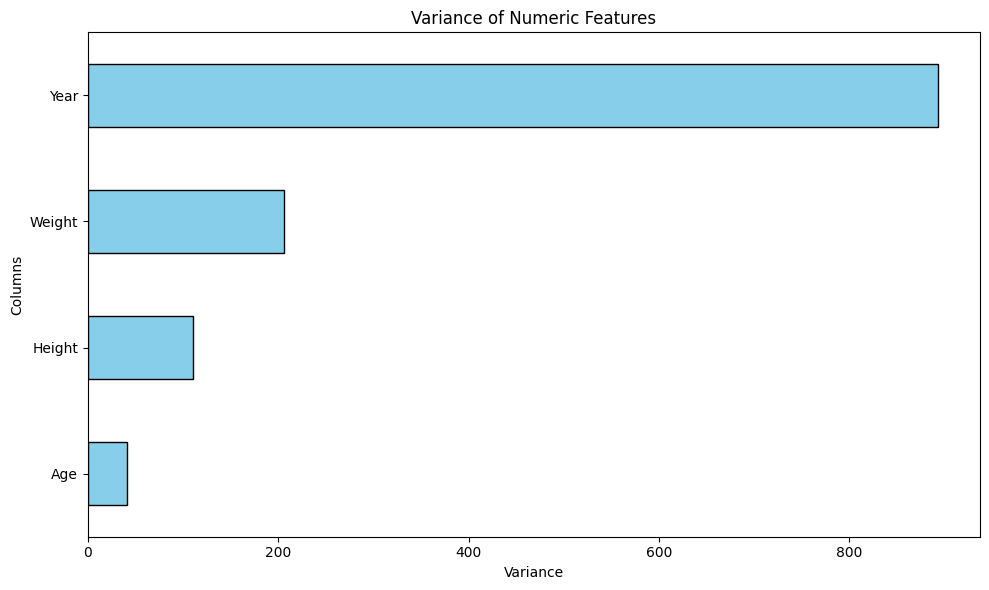

In [ ]:
# Compute variances
variances = df.var(numeric_only=True)

# Plot variances
plt.figure(figsize=(10, 6))
variances.sort_values().plot(kind="barh", color="skyblue", edgecolor="black")
plt.title("Variance of Numeric Features")
plt.xlabel("Variance")
plt.ylabel("Columns")
plt.tight_layout()
plt.show()


##Visualization

In [11]:
# Group by Medal and calculate mean age
mean_age_by_medal = df.groupby('Medal')['Age'].mean()
print(mean_age_by_medal)

Medal
Bronze     25.294923
Gold       25.603276
MISSING    24.491153
Silver     25.389524
Name: Age, dtype: float64



Mean Age by Sport:
Sport
Roque                  39.75
Art Competitions       39.26
Polo                   33.42
Equestrianism          33.31
Jeu De Paume           32.45
                       ...  
Swimming               20.08
Rhythmic Gymnastics    18.74
Military Ski Patrol    18.58
Rugby                  16.86
Lacrosse               15.72
Name: Age, Length: 66, dtype: float64


C:\Users\shvac\AppData\Local\Temp\ipykernel_10588\671766965.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mean_age_by_sport.index,


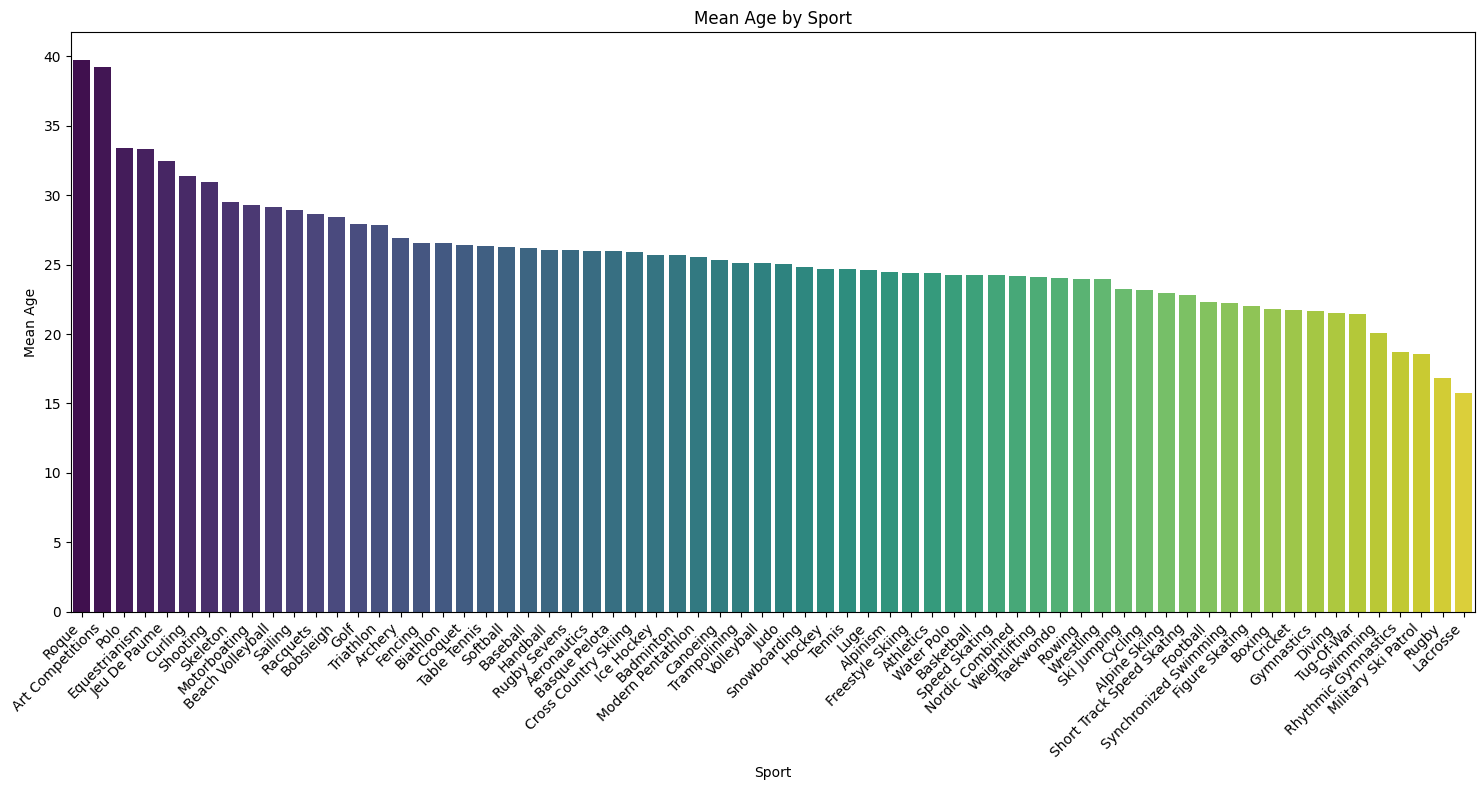

C:\Users\shvac\AppData\Local\Temp\ipykernel_10588\671766965.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Sport', y='Age', data=df, palette='viridis')


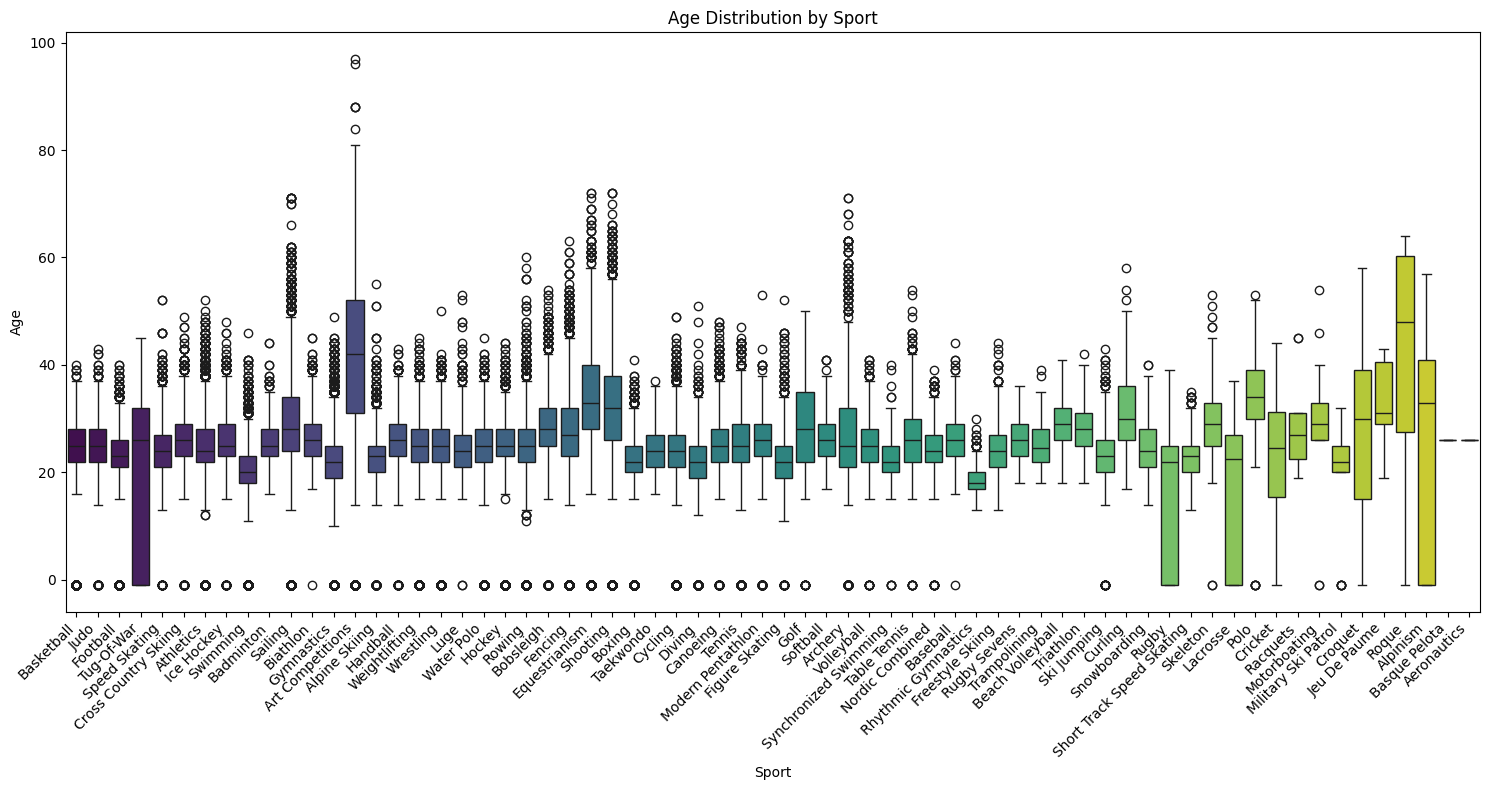

In [20]:
# Calculate mean age by sport
mean_age_by_sport = df.groupby('Sport')['Age'].mean().round(2).sort_values(ascending=False)
print("\nMean Age by Sport:")
print(mean_age_by_sport)

# Create a bar plot using seaborn
plt.figure(figsize=(15, 8))
sns.barplot(x=mean_age_by_sport.index, 
           y=mean_age_by_sport.values,
           palette='viridis')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')
plt.title('Mean Age by Sport')
plt.xlabel('Sport')
plt.ylabel('Mean Age')

# Adjust layout to prevent label cutoff
plt.tight_layout()
plt.show()

# For a more detailed view, let's also create a box plot
plt.figure(figsize=(15, 8))
sns.boxplot(x='Sport', y='Age', data=df, palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.title('Age Distribution by Sport')
plt.xlabel('Sport')
plt.ylabel('Age')
plt.tight_layout()
plt.show()

In [22]:
# Get statistics for sports with highest and lowest median ages
sport_stats = df.groupby('Sport')['Age'].agg(['median', 'mean', 'std', 'min', 'max']).round(2)
sport_stats = sport_stats.sort_values('median', ascending=False)

print("\nTop 5 Sports with Highest Median Age:")
print(sport_stats.head())
print("\nTop 5 Sports with Lowest Median Age:")
print(sport_stats.tail())

# Calculate the age range for each sport
sport_stats['age_range'] = sport_stats['max'] - sport_stats['min']
print("\nSports with Widest Age Range:")
print(sport_stats.nlargest(5, 'age_range')[['min', 'max', 'age_range']])


Top 5 Sports with Highest Median Age:
                  median   mean    std  min   max
Sport                                            
Roque               48.0  39.75  29.59 -1.0  64.0
Art Competitions    42.0  39.26  20.16 -1.0  97.0
Polo                34.0  33.42  10.43 -1.0  53.0
Equestrianism       33.0  33.31  10.29 -1.0  72.0
Alpinism            33.0  24.48  20.96 -1.0  57.0

Top 5 Sports with Lowest Median Age:
                     median   mean    std   min   max
Sport                                                
Rugby                  22.0  16.86  11.99  -1.0  39.0
Gymnastics             22.0  21.69   6.84  -1.0  49.0
Military Ski Patrol    22.0  18.58  10.61  -1.0  32.0
Swimming               20.0  20.08   4.89  -1.0  46.0
Rhythmic Gymnastics    18.0  18.74   2.51  13.0  30.0

Sports with Widest Age Range:
                  min   max  age_range
Sport                                 
Art Competitions -1.0  97.0       98.0
Equestrianism    -1.0  72.0       73.0
Shooting

Detailed Statistics for Selected Sports:
             Age                                  Year      
           count   mean median    std  min   max   min   max
Sport                                                       
Alpinism      25  24.48   33.0  20.96 -1.0  57.0  1924  1936
Polo          95  33.42   34.0  10.43 -1.0  53.0  1900  1936
Rugby        162  16.86   22.0  11.99 -1.0  39.0  1900  1924
Tug-Of-War   170  21.46   26.0  14.32 -1.0  45.0  1900  1920


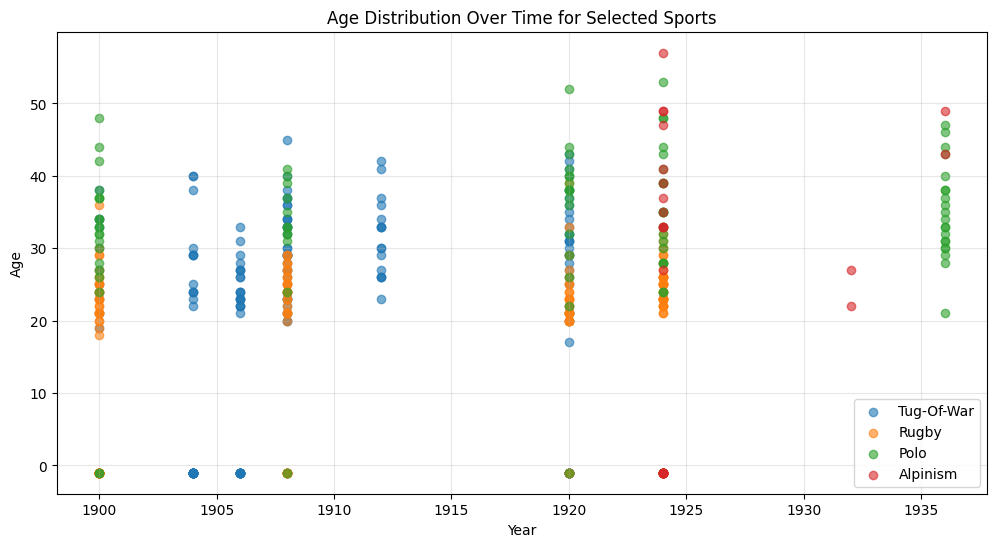

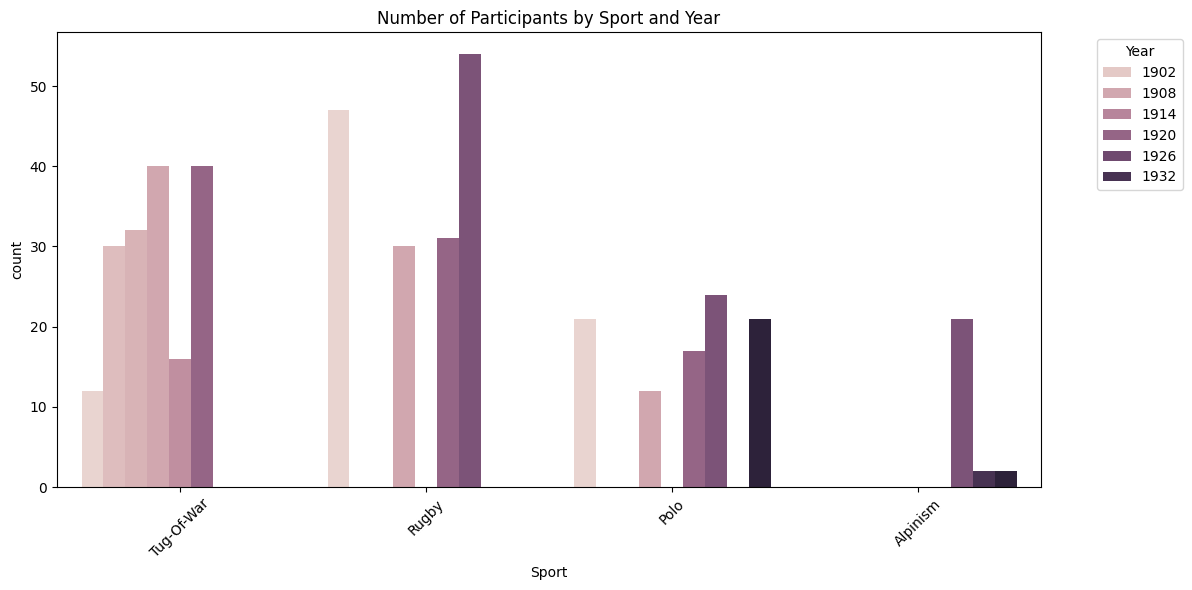


Participation Years for each Sport:

Tug-Of-War: [1900, 1904, 1906, 1908, 1912, 1920]

Rugby: [1900, 1908, 1920, 1924]

Polo: [1900, 1908, 1920, 1924, 1936]

Alpinism: [1924, 1932, 1936]


In [23]:
# List of sports to analyze
outlier_sports = ['Tug-Of-War', 'Rugby', 'Polo', 'Alpinism']

# Filter the dataframe for these sports
outlier_sports_df = df[df['Sport'].isin(outlier_sports)]

# Get detailed statistics for these sports
outlier_stats = outlier_sports_df.groupby('Sport').agg({
    'Age': ['count', 'mean', 'median', 'std', 'min', 'max'],
    'Year': ['min', 'max']  # To see when these sports were in the Olympics
}).round(2)

print("Detailed Statistics for Selected Sports:")
print(outlier_stats)

# Create a timeline visualization
plt.figure(figsize=(12, 6))
for sport in outlier_sports:
    sport_data = df[df['Sport'] == sport]
    plt.scatter(sport_data['Year'], sport_data['Age'], label=sport, alpha=0.6)

plt.legend()
plt.title('Age Distribution Over Time for Selected Sports')
plt.xlabel('Year')
plt.ylabel('Age')
plt.grid(True, alpha=0.3)
plt.show()

# Show distribution of participants by year
plt.figure(figsize=(12, 6))
sns.countplot(data=outlier_sports_df, x='Sport', hue='Year')
plt.title('Number of Participants by Sport and Year')
plt.xticks(rotation=45)
plt.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Additional historical context
print("\nParticipation Years for each Sport:")
for sport in outlier_sports:
    years = sorted(df[df['Sport'] == sport]['Year'].unique())
    print(f"\n{sport}: {years}")

C:\Users\shvac\AppData\Local\Temp\ipykernel_10588\2181655406.py:9: UserWarning: 
The palette list has fewer values (3) than needed (4) and will cycle, which may produce an uninterpretable plot.
  sns.kdeplot(data=medal_data, x='Age', hue='Medal', palette=['gold', 'silver', 'brown'])


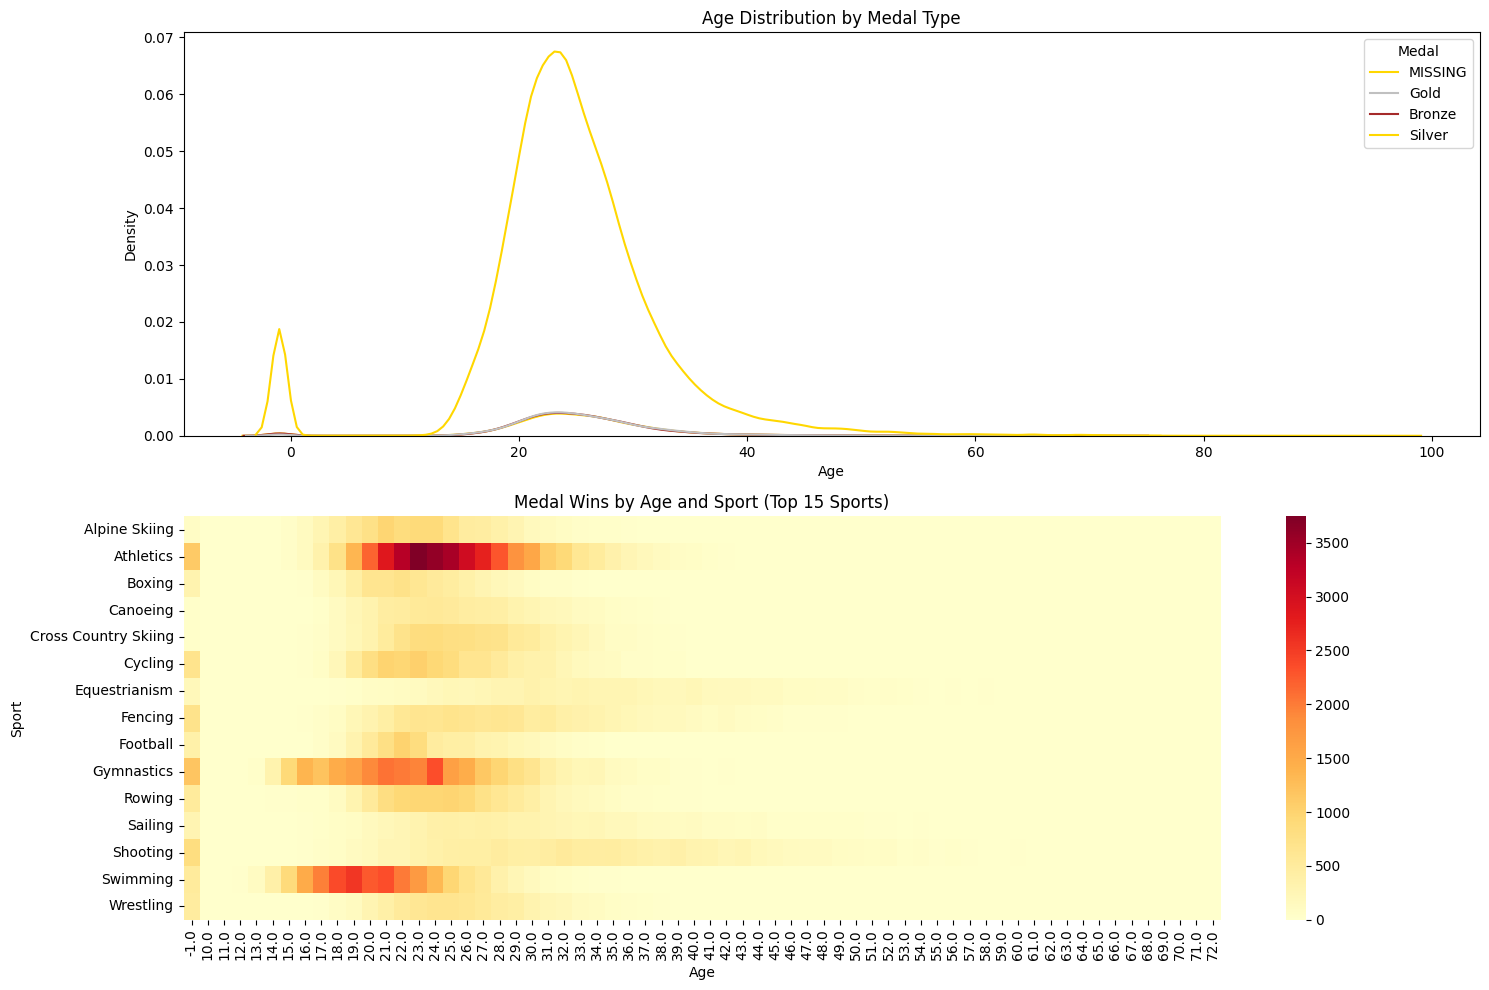


Most Successful Age for Each Sport (Top 15):
                     Sport   Age  Medal_Count
180              Athletics  23.0         3744
1552              Swimming  19.0         2546
846             Gymnastics  24.0         2347
542                Cycling  23.0         1051
748               Football  22.0         1023
1198                Rowing  25.0          988
9            Alpine Skiing  21.0          973
472   Cross Country Skiing  24.0          857
1320              Shooting  -1.0          821
388                 Boxing  22.0          728
655                Fencing  -1.0          715
1864             Wrestling  24.0          646
1522         Speed Skating  24.0          608
416               Canoeing  24.0          563
909                 Hockey  24.0          554

Medal Distribution by Age Groups:
Medal      Bronze  Gold  MISSING  Silver
Age_Group                               
Under 20     1802  1837    42149    1773
20-25        5247  5348    87629    5056
26-30        3865  

C:\Users\shvac\AppData\Local\Temp\ipykernel_10588\2181655406.py:51: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_medals = medal_data.groupby(['Age_Group', 'Medal']).size().unstack()


<Figure size 1200x600 with 0 Axes>

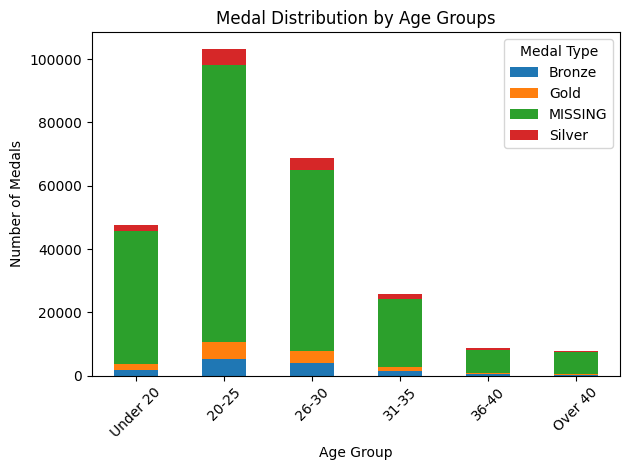

In [24]:
# Filter out rows with no medals (where Medal is NaN)
medal_data = df[df['Medal'].notna()]

# Create a figure with multiple subplots
plt.figure(figsize=(15, 10))

# 1. Overall Medal Distribution by Age
plt.subplot(2, 1, 1)
sns.kdeplot(data=medal_data, x='Age', hue='Medal', palette=['gold', 'silver', 'brown'])
plt.title('Age Distribution by Medal Type')
plt.xlabel('Age')
plt.ylabel('Density')

# 2. Top 15 Sports with Most Medals
top_15_sports = medal_data['Sport'].value_counts().head(15).index

# Create medal counts by sport and age
medal_sport_age = medal_data[medal_data['Sport'].isin(top_15_sports)].groupby(['Sport', 'Age', 'Medal']).size().reset_index(name='Count')

# Create heatmap of medal wins by age and sport
plt.subplot(2, 1, 2)
pivot_data = medal_data[medal_data['Sport'].isin(top_15_sports)].pivot_table(
    values='Medal',
    index='Sport',
    columns='Age',
    aggfunc='count',
    fill_value=0
)

sns.heatmap(pivot_data, cmap='YlOrRd')
plt.title('Medal Wins by Age and Sport (Top 15 Sports)')
plt.xlabel('Age')
plt.ylabel('Sport')

plt.tight_layout()
plt.show()

# Calculate and display the most successful age for each sport
most_successful_age = medal_data.groupby(['Sport', 'Age']).size().reset_index(name='Medal_Count')
top_ages = most_successful_age.loc[most_successful_age.groupby('Sport')['Medal_Count'].idxmax()]
top_ages = top_ages.sort_values('Medal_Count', ascending=False)

print("\nMost Successful Age for Each Sport (Top 15):")
print(top_ages.head(15)[['Sport', 'Age', 'Medal_Count']])

# Additional analysis: Medal distribution by age groups
medal_data['Age_Group'] = pd.cut(medal_data['Age'], 
                                bins=[0, 20, 25, 30, 35, 40, 100],
                                labels=['Under 20', '20-25', '26-30', '31-35', '36-40', 'Over 40'])

age_group_medals = medal_data.groupby(['Age_Group', 'Medal']).size().unstack()
print("\nMedal Distribution by Age Groups:")
print(age_group_medals)

# Visualize medal distribution by age groups
plt.figure(figsize=(12, 6))
age_group_medals.plot(kind='bar', stacked=True)
plt.title('Medal Distribution by Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Number of Medals')
plt.legend(title='Medal Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\shvac\AppData\Local\Temp\ipykernel_10588\306133190.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Medal', y='Age', data=medal_data, palette=['gold', 'silver', 'brown'], ax=ax1)
C:\Users\shvac\AppData\Local\Temp\ipykernel_10588\306133190.py:5: UserWarning: 
The palette list has fewer values (3) than needed (4) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(x='Medal', y='Age', data=medal_data, palette=['gold', 'silver', 'brown'], ax=ax1)
C:\Users\shvac\AppData\Local\Temp\ipykernel_10588\306133190.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Medal', y='Age', data=medal_data, palette=['gold', 'silver', 'brown'], ax=ax2)
C:\Users\shvac\Ap

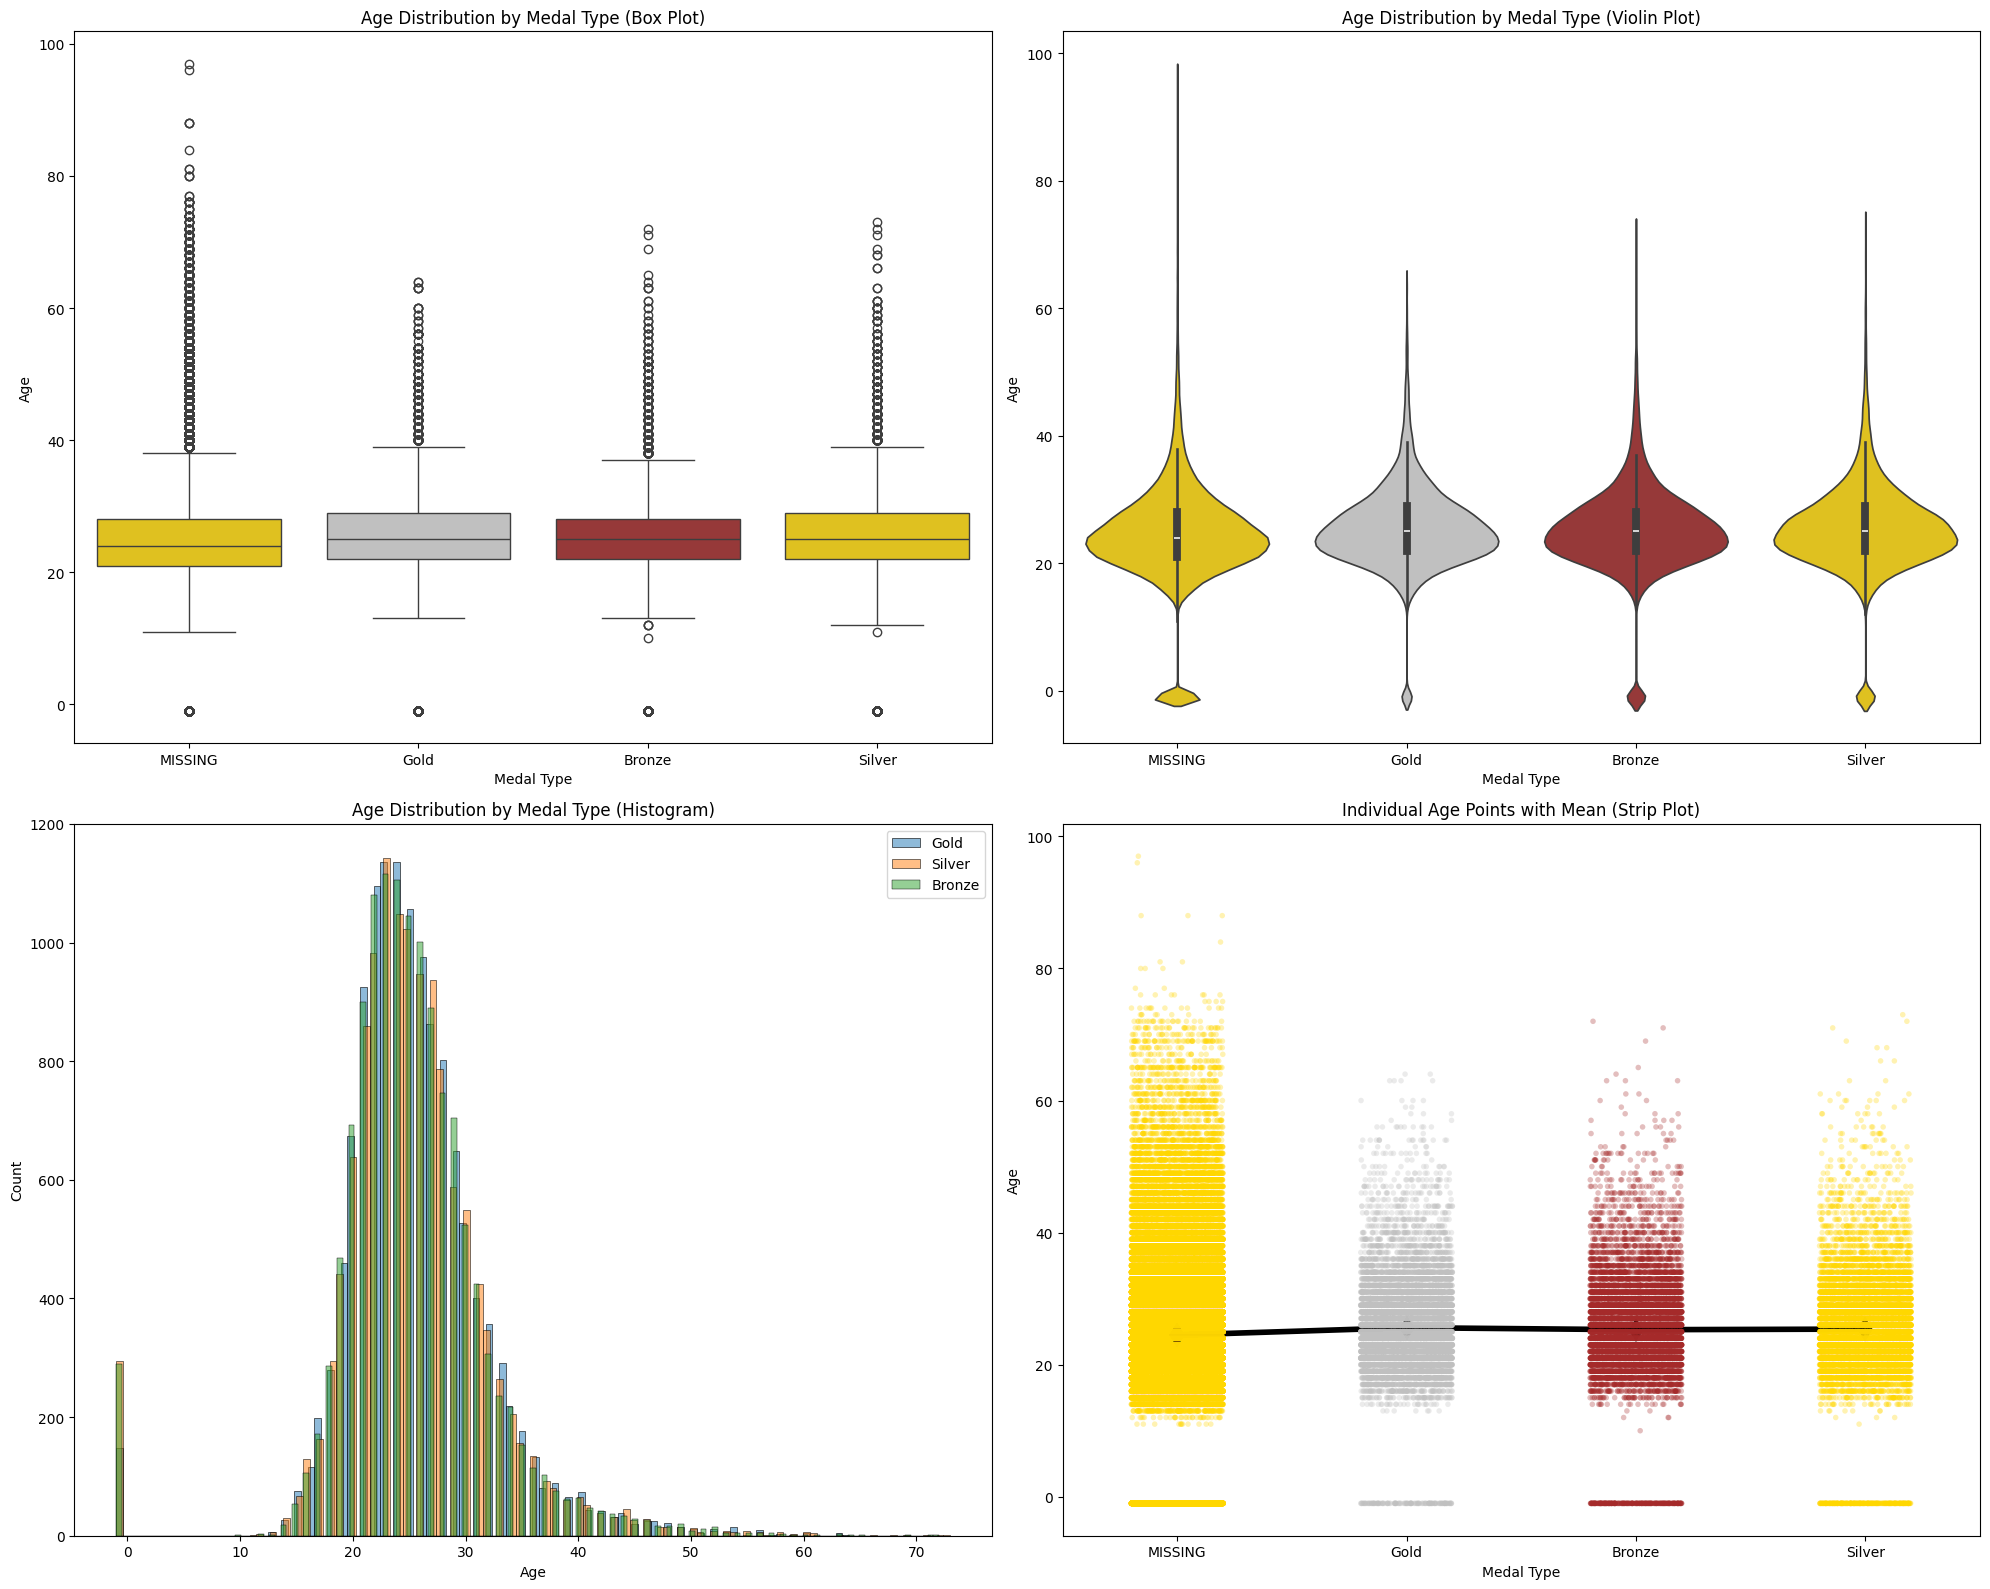


Statistical Summary of Age by Medal Type:
            count   mean   std  min   25%   50%   75%   max
Medal                                                      
Bronze    13295.0  25.29  6.97 -1.0  22.0  25.0  28.0  72.0
Gold      13372.0  25.60  6.50 -1.0  22.0  25.0  29.0  64.0
MISSING  231333.0  24.49  8.11 -1.0  21.0  24.0  28.0  97.0
Silver    13116.0  25.39  7.17 -1.0  22.0  25.0  29.0  73.0

Most Common Age (Mode) for Each Medal Type:
Medal
Bronze     23.0
Gold       23.0
MISSING    23.0
Silver     23.0
Name: Age, dtype: float64

Percentage of Medals Won by Age Groups:
Medal      Bronze   Gold  MISSING  Silver
Age_Group                                
Under 20    13.86  13.89    18.94   13.83
20-25       40.34  40.44    39.37   39.44
26-30       29.72  28.86    25.70   29.69
31-35       10.28  10.92     9.68   10.90
36-40        3.21   3.34     3.32    3.40
Over 40      2.59   2.54     3.00    2.75


In [25]:
# Create a figure with multiple visualizations
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 16))

# 1. Box plot
sns.boxplot(x='Medal', y='Age', data=medal_data, palette=['gold', 'silver', 'brown'], ax=ax1)
ax1.set_title('Age Distribution by Medal Type (Box Plot)')
ax1.set_xlabel('Medal Type')
ax1.set_ylabel('Age')

# 2. Violin plot
sns.violinplot(x='Medal', y='Age', data=medal_data, palette=['gold', 'silver', 'brown'], ax=ax2)
ax2.set_title('Age Distribution by Medal Type (Violin Plot)')
ax2.set_xlabel('Medal Type')
ax2.set_ylabel('Age')

# 3. Histogram
for medal in ['Gold', 'Silver', 'Bronze']:
    sns.histplot(data=medal_data[medal_data['Medal'] == medal], 
                x='Age', 
                label=medal,
                alpha=0.5,
                ax=ax3)
ax3.set_title('Age Distribution by Medal Type (Histogram)')
ax3.set_xlabel('Age')
ax3.set_ylabel('Count')
ax3.legend()

# 4. Strip plot with means
sns.stripplot(x='Medal', y='Age', data=medal_data, 
             alpha=0.3, jitter=0.2, size=4, 
             palette=['gold', 'silver', 'brown'], ax=ax4)
sns.pointplot(x='Medal', y='Age', data=medal_data, 
             color='black', markers='d', scale=1.5, ax=ax4)
ax4.set_title('Individual Age Points with Mean (Strip Plot)')
ax4.set_xlabel('Medal Type')
ax4.set_ylabel('Age')

plt.tight_layout()
plt.show()

# Print statistical summary
print("\nStatistical Summary of Age by Medal Type:")
print(medal_data.groupby('Medal')['Age'].describe().round(2))

# Calculate mode age for each medal type
mode_ages = medal_data.groupby('Medal')['Age'].agg(lambda x: x.mode().iloc[0])
print("\nMost Common Age (Mode) for Each Medal Type:")
print(mode_ages)

# Calculate percentage of medals won by different age groups
medal_data['Age_Group'] = pd.cut(medal_data['Age'], 
                                bins=[0, 20, 25, 30, 35, 40, 100],
                                labels=['Under 20', '20-25', '26-30', '31-35', '36-40', 'Over 40'])

age_group_percentages = pd.crosstab(medal_data['Age_Group'], 
                                   medal_data['Medal'], 
                                   normalize='columns') * 100

print("\nPercentage of Medals Won by Age Groups:")
print(age_group_percentages.round(2))

C:\Users\shvac\AppData\Local\Temp\ipykernel_10588\3922353525.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x='Sport', y='Age', data=top_sports_data,
C:\Users\shvac\AppData\Local\Temp\ipykernel_10588\3922353525.py:16: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(x='Sport', y='Age', data=top_sports_data,
C:\Users\shvac\AppData\Local\Temp\ipykernel_10588\3922353525.py:16: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(x='Sport', y='Age', data=top_sports_data,


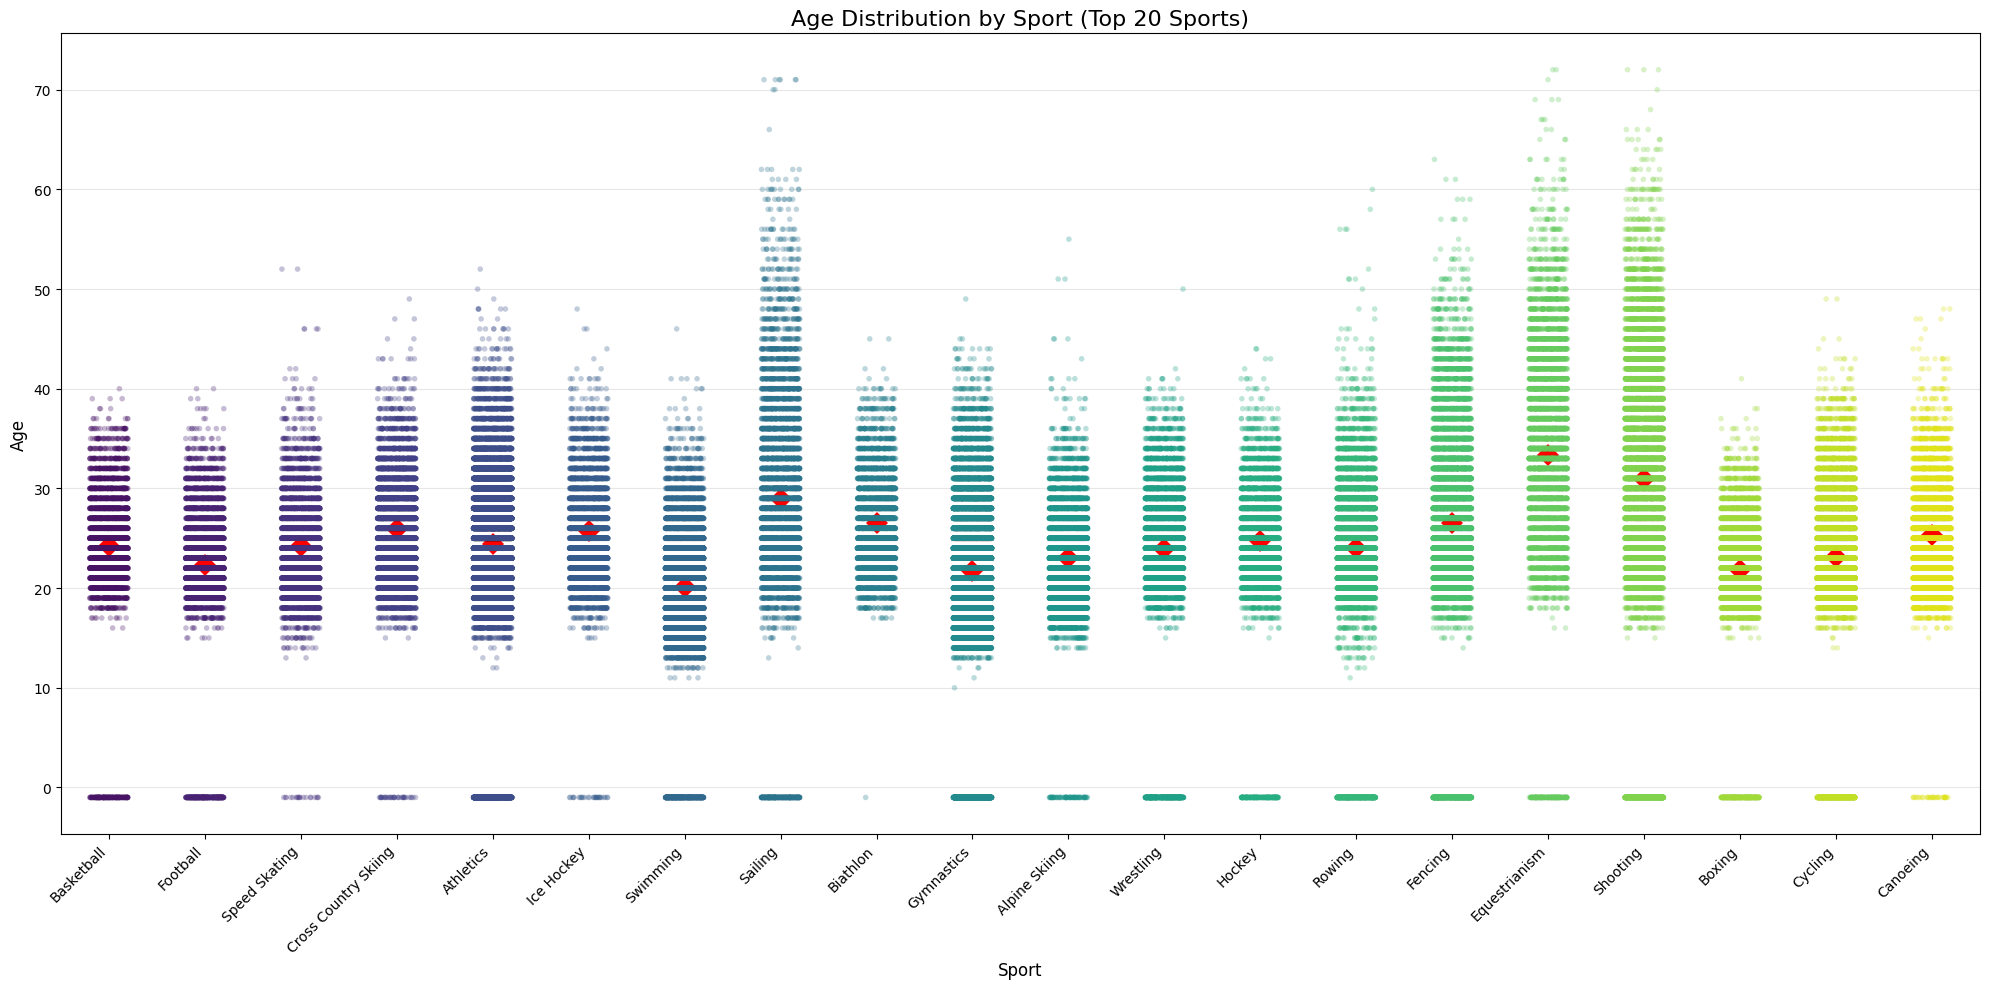


Age Statistics by Sport (Top 20):
                      count   mean  median    std  min   max
Sport                                                       
Equestrianism          6344  33.31    33.0  10.29 -1.0  72.0
Shooting              11448  30.95    32.0  12.13 -1.0  72.0
Sailing                6586  28.93    28.0  10.08 -1.0  71.0
Fencing               10735  26.57    27.0   9.70 -1.0  63.0
Biathlon               4893  26.53    26.0   4.31 -1.0  45.0
Cross Country Skiing   9133  25.90    26.0   4.60 -1.0  49.0
Ice Hockey             5516  25.69    25.0   4.83 -1.0  48.0
Canoeing               6171  25.35    25.0   4.95 -1.0  48.0
Hockey                 5417  24.71    25.0   6.45 -1.0  44.0
Athletics             38624  24.40    24.0   6.16 -1.0  52.0
Basketball             4536  24.25    25.0   6.46 -1.0  40.0
Speed Skating          5613  24.22    24.0   4.50 -1.0  52.0
Rowing                10595  23.97    25.0   7.15 -1.0  60.0
Wrestling              7154  23.96    25.0   7.86 

In [26]:
# Get top 20 sports by number of participants
top_20_sports = df['Sport'].value_counts().head(20).index

# Filter data for top 20 sports
top_sports_data = df[df['Sport'].isin(top_20_sports)]

# Create figure with larger size
plt.figure(figsize=(20, 10))

# Create strip plot with means
sns.stripplot(x='Sport', y='Age', data=top_sports_data, 
             alpha=0.3, jitter=0.2, size=4, 
             palette='viridis')

# Add mean points
sns.pointplot(x='Sport', y='Age', data=top_sports_data, 
             color='red', markers='D', scale=1.5, 
             join=False)  # Don't join the points

# Customize the plot
plt.title('Age Distribution by Sport (Top 20 Sports)', fontsize=16)
plt.xlabel('Sport', fontsize=12)
plt.ylabel('Age', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Add grid for better readability
plt.grid(True, axis='y', alpha=0.3)

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Show the plot
plt.show()

# Print statistical summary for each sport
print("\nAge Statistics by Sport (Top 20):")
stats_summary = top_sports_data.groupby('Sport')['Age'].agg([
    'count',
    'mean',
    'median',
    'std',
    'min',
    'max'
]).round(2)

print(stats_summary.sort_values('mean', ascending=False))